<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%20007/Ejemplo_2_lluvia_en_cba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# datos espaciales
### Coderhouse - Data Science
Profe Jorge Ruiz

In [ ]:
#pip install geopandas

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning:

driver TopoJSON does not support open option DRIVER



,id,departamento,cabecera,provincia,geometry
0,393,PRESIDENTE ROQUE SAENZ PEÑA,LABOULAYE,CORDOBA,"POLYGON ((-62.81968 -33.89623, -62.81368 -33.8..."
1,341,TERCERO ARRIBA,OLIVA,CORDOBA,"POLYGON ((-63.1178 -32.00084, -63.1242 -31.999..."
2,342,JUAREZ CELMAN,LA CARLOTA,CORDOBA,"POLYGON ((-63.55556 -32.83083, -63.52395 -32.8..."
3,322,SOBREMONTE,SAN FRANCISCO DEL CHA¥AR,CORDOBA,"POLYGON ((-63.72522 -29.65553, -63.72762 -29.6..."
4,323,TULUMBA,VILLA TULUMBA,CORDOBA,"POLYGON ((-63.9373 -30.0884, -63.9353 -30.0939..."
5,324,ISCHILIN,DEAN FUNES,CORDOBA,"POLYGON ((-64.26142 -30.47012, -64.26022 -30.4..."
6,325,TOTORAL,VILLA DEL TOTORAL,CORDOBA,"POLYGON ((-63.58317 -30.53557, -63.58877 -30.5..."
7,326,CRUZ DEL EJE,CRUZ DEL EJE,CORDOBA,"POLYGON ((-64.98369 -30.00975, -64.98369 -30.0..."
8,327,COLON,JESUS MARIA,CORDOBA,"POLYGON ((-63.83686 -31.0328, -63.83606 -31.08..."
9,328,PUNILLA,COSQUIN,CORDOBA,"POLYGON ((-64.44789 -31.38646, -64.45749 -31.3..."


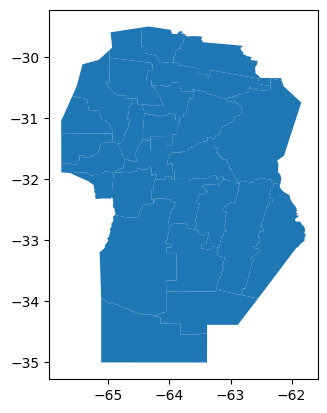

In [13]:
import geopandas as gpd


# Ruta del archivo TopoJSON
ruta_archivo = 'https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-II/refs/heads/main/Clase%20007/departamentos-cordoba.topojson'

# Leer el archivo TopoJSON como un DataFrame de GeoPandas
gdf = gpd.read_file(ruta_archivo, driver='TopoJSON')

# Visualizar el mapa
gdf.plot()

# otros topojson de Argentina pueden encontrarlos en https://github.com/mgaitan/departamentos_argentina

gdf

In [14]:
import pandas as pd

# Ruta del archivo CSV de precipitaciones
ruta_precipitaciones = 'https://raw.githubusercontent.com/Jorge-Ruiz-Troccoli/Data-Science-II/refs/heads/main/Clase%20007/Precipitaciones%20C%C3%B3rdoba.csv'

# Leer el archivo CSV
df_precipitaciones = pd.read_csv(ruta_precipitaciones, sep=";")
df_precipitaciones

# precipitaciones para el mes de abril 2021

,departamento,lluvia
0,CAPITAL,50.000000
1,CALAMUCHITA,54.400000
2,COLON,53.200000
3,GENERAL ROCA,53.666667
4,GRAL SAN MARTIN,94.300000
5,JUAREZ CELMAN,67.171429
6,MARCOS JUAREZ,135.711111
7,PTE ROQUE SAENZ PENIA,64.733333
8,RIO CUARTO,64.350000
9,RIO PRIMERO,28.933333


In [15]:
# hay nombres de departamentos con errores

df_precipitaciones.replace("PTE ROQUE SAENZ PENIA","PRESIDENTE ROQUE SAENZ PEÑA", inplace=True)

df_precipitaciones.replace("GRAL SAN MARTIN","GENERAL SAN MARTIN", inplace=True)
df_precipitaciones

,departamento,lluvia
0,CAPITAL,50.000000
1,CALAMUCHITA,54.400000
2,COLON,53.200000
3,GENERAL ROCA,53.666667
4,GENERAL SAN MARTIN,94.300000
5,JUAREZ CELMAN,67.171429
6,MARCOS JUAREZ,135.711111
7,PRESIDENTE ROQUE SAENZ PEÑA,64.733333
8,RIO CUARTO,64.350000
9,RIO PRIMERO,28.933333


In [16]:
# Unir los datos de lluvia con el DataFrame de GeoPandas

gdf_merge = gdf.merge(df_precipitaciones, on='departamento', how='inner')
gdf_merge

,id,departamento,cabecera,provincia,geometry,lluvia
0,393,PRESIDENTE ROQUE SAENZ PEÑA,LABOULAYE,CORDOBA,"POLYGON ((-62.81968 -33.89623, -62.81368 -33.8...",64.733333
1,341,TERCERO ARRIBA,OLIVA,CORDOBA,"POLYGON ((-63.1178 -32.00084, -63.1242 -31.999...",55.750000
2,342,JUAREZ CELMAN,LA CARLOTA,CORDOBA,"POLYGON ((-63.55556 -32.83083, -63.52395 -32.8...",67.171429
3,323,TULUMBA,VILLA TULUMBA,CORDOBA,"POLYGON ((-63.9373 -30.0884, -63.9353 -30.0939...",37.300000
4,325,TOTORAL,VILLA DEL TOTORAL,CORDOBA,"POLYGON ((-63.58317 -30.53557, -63.58877 -30.5...",12.800000
5,327,COLON,JESUS MARIA,CORDOBA,"POLYGON ((-63.83686 -31.0328, -63.83606 -31.08...",53.200000
6,329,CAPITAL,CORDOBA,CORDOBA,"POLYGON ((-64.05574 -31.43486, -64.05574 -31.5...",50.000000
7,339,GENERAL SAN MARTIN,VILLA MARIA,CORDOBA,"POLYGON ((-63.1178 -32.00084, -63.01936 -32.02...",94.300000
8,330,SANTA MARIA,ALTA GRACIA,CORDOBA,"POLYGON ((-63.9441 -31.55862, -64.01533 -31.60...",40.800000
9,333,SAN ALBERTO,VILLA CURA BROCHERO,CORDOBA,"POLYGON ((-64.90246 -31.89799, -64.90326 -31.8...",61.600000


In [17]:
len(df_precipitaciones)== len(gdf_merge)

#verificar que el total de filas sea igual, sino falto modificar algún nombre

True

/tmp/ipykernel_30850/3983998459.py:6: UserWarning:

Only specify one of 'column' or 'color'. Using 'color'.



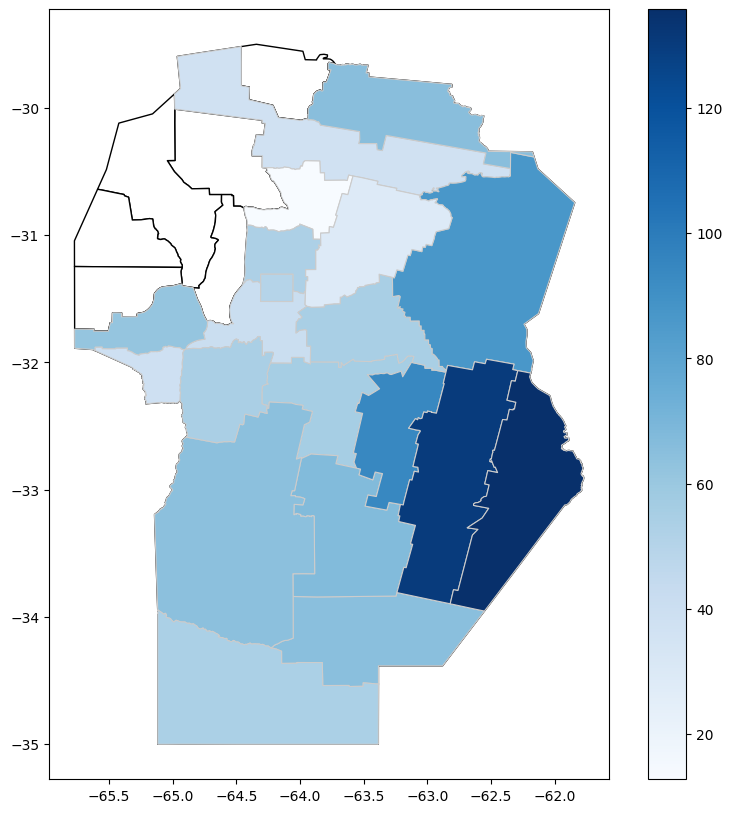

In [20]:
# Visualizar el mapa coroplético
import matplotlib.pyplot as plt

# Crear el gráfico de los departamentos
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='lluvia', ax=ax, color='white', edgecolor='black')

# Agregar la capa de lluvia
gdf_merge.plot(ax=ax, column='lluvia', cmap='Blues', linewidth=0.8, edgecolor='0.8', legend=True)

# Mostrar el gráfico
plt.show()




In [21]:
# Guardar el gráfico en un archivo de imagen si lo necesitamos para un informe, presentación, etc.
fig.savefig('mapa_lluvia_cordoba.png')

In [24]:
# Crear el mapa choropleth con plotly express
import geopandas as gpd
import plotly.express as px

fig = px.choropleth_mapbox(
    gdf_merge,
    geojson=gdf_merge.geometry.__geo_interface__,
    locations=gdf_merge.index,  # Utiliza el índice del GeoDataFrame como ubicaciones
    color='lluvia',
    color_continuous_scale='YlGnBu',
    hover_name=gdf_merge.index,
    mapbox_style="carto-positron",
    center={"lat": -32, "lon": -64},
    zoom=5,
    opacity=0.7,
    labels={'lluvia': 'Lluvia'},
    title='Mapa de Precipitaciones por departamentos en Córdoba'
)

fig.show()

In [23]:
gdf_merge.set_index('departamento', inplace=True)

In [27]:
import plotly.graph_objects as go


gdf_merge.lluvia= gdf_merge.lluvia.astype(int)
gdf_merge= gdf_merge.sort_values(by="lluvia") # vamos a darle un orden a los registros de lluvia desc

# Create a bar plot with the sorted departments on the y-axis
fig = go.Figure(data=[go.Bar(
    y=gdf_merge.index,
    x=gdf_merge['lluvia'],
    orientation='h',
    text=gdf_merge['lluvia'],
     textposition='outside'

)])

# Update the layout of the plot
fig.update_layout(
    title='Acumulados de precipitaciones por departamentos en la provincia de Córdoba',
    xaxis_title='Lluvia (mm)',
    yaxis_title='Departamentos',
    yaxis_categoryarray=gdf_merge.index,
    #yaxis_tickangle= -45
)

# Show the plot
fig.show()



revisar más info en https://plotly.com/python/creating-and-updating-figures/